In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# ---- 実験条件（毎回ここだけ書き換える） ----
KAPPA_PURE = 0.145    # 純水の比伝導率 (mS/m)：実験1の測定値
M_PbSO4    = 303.26   # PbSO4のモル質量 (g/mol)

LABEL = {"Pb(NO3)2": "Pb(NO~3~)~2~",
         "Na2SO4":   "Na~2~SO~4~",
         "NaNO3":    "NaNO~3~"}

df  = pd.read_csv("../data/03_conductivity.csv")
sat = pd.read_csv("../data/03_saturated.csv")
df["salt"] = df["salt"].map(LABEL)
ORDER = list(dict.fromkeys(df["salt"]))


def md_table(frame, caption):
    """DataFrameをキャプション付きのMarkdown表として出力する"""
    txt = frame.to_markdown(disable_numparse=True,
                            colalign=["left"] + ["right"] * len(frame.columns))
    display(Markdown(f"{caption}\n\n{txt}"))


def to_wide(d, col, fmt):
    """縦持ちデータを「塩 × 濃度」の表に整形し、指定桁で文字列化する"""
    w = d.pivot(index="salt", columns="conc_mol_L", values=col).reindex(ORDER)
    w.columns = [f"{c} mol/L" for c in w.columns]
    w.index.name = "塩"
    w = w.astype(object)
    for c in w.columns:
        w[c] = w[c].map(lambda v: format(v, fmt))
    return w

def sci(x, n=3):
    """1.24e-07 のような値を LaTeX の 1.240×10^{-7} 形式にする"""
    s = f"{x:.{n}e}"
    m, e = s.split("e")
    return rf"{m} \times 10^{{{int(e)}}}"

## 4. 結果

### 【実験1：純水の比伝導率の測定】

伝導率計はNo.4で、セルコンスタントの値は100.1、液温は21.5 ℃で、
純水の比伝導率は0.145 mS/mであった。

### 【実験3：Pb(NO~3~)~2~、Na~2~SO~4~およびNaNO~3~水溶液の比伝導率の測定】

測定した各塩の比伝導率を表1に示す。なお、比伝導率の値は
実験1で測定した純水の比伝導率によって補正された値である。

In [2]:
md_table(to_wide(df, "kappa_mS_m", ".1f"), "表1　各塩の比伝導率 (mS/m)")

表1　各塩の比伝導率 (mS/m)

| 塩           |   0.001 mol/L |   0.0025 mol/L |   0.005 mol/L |   0.01 mol/L |
|:-------------|--------------:|---------------:|--------------:|-------------:|
| Pb(NO~3~)~2~ |          28.5 |           63.7 |         120.0 |        215.9 |
| Na~2~SO~4~   |          23.6 |           58.1 |         111.1 |        204.9 |
| NaNO~3~      |          11.7 |           29.4 |          57.3 |        111.1 |

In [3]:
# mS/m → S/cm : ×1e-5   /   mol/L → mol/cm3 : ×1e-3
df["Lambda_eq"] = (df["kappa_mS_m"] * 1e-5) / (df["zv"] * df["conc_mol_L"] * 1e-3)

md_table(to_wide(df, "Lambda_eq", ".1f"), "表2　各塩のモル伝導率 (S･cm^2^/mol)")

表2　各塩のモル伝導率 (S･cm^2^/mol)

| 塩           |   0.001 mol/L |   0.0025 mol/L |   0.005 mol/L |   0.01 mol/L |
|:-------------|--------------:|---------------:|--------------:|-------------:|
| Pb(NO~3~)~2~ |         142.5 |          127.4 |         120.0 |        108.0 |
| Na~2~SO~4~   |         118.0 |          116.2 |         111.1 |        102.4 |
| NaNO~3~      |         117.0 |          117.6 |         114.6 |        111.1 |

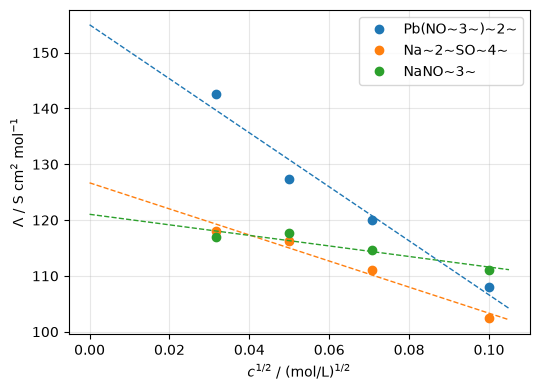

図1　濃度の平方根とモル伝導率の関係

図1の近似直線の式より、各塩の無限希釈におけるモル伝導率は以下のとおりである。

- Pb(NO~3~)~2~ : 154.99 S cm^2^/mol
- Na~2~SO~4~ : 126.67 S cm^2^/mol
- NaNO~3~ : 121.04 S cm^2^/mol

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 4))
lam = {}

for name in ORDER:
    g = df[df["salt"] == name]
    x = np.sqrt(g["conc_mol_L"])
    y = g["Lambda_eq"]
    a, b = np.polyfit(x, y, 1)        # a=傾き, b=切片(=Λ∞)
    lam[name] = b
    xs = np.linspace(0, x.max() * 1.05, 50)
    p = ax.plot(x, y, "o", label=name)
    ax.plot(xs, a * xs + b, "--", lw=1, color=p[0].get_color())

ax.set_xlabel(r"$c^{1/2}$ / (mol/L)$^{1/2}$")
ax.set_ylabel(r"$\Lambda$ / S cm$^2$ mol$^{-1}$")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

display(Markdown(
    "図1　濃度の平方根とモル伝導率の関係\n\n"
    "図1の近似直線の式より、各塩の無限希釈におけるモル伝導率は以下のとおりである。\n\n"
    + "\n".join(f"- {k} : {v:.2f} S cm^2^/mol" for k, v in lam.items())))

In [5]:
L_PbSO4 = lam["Pb(NO~3~)~2~"] + lam["Na~2~SO~4~"] - lam["NaNO~3~"]

display(Markdown(
    "(8)式より、PbSO~4~の無限希釈におけるモル伝導率は以下のように求められる。\n\n"
    r"$$\Lambda^{\infty}\left[\tfrac{1}{2}\mathrm{PbSO_4}\right] = "
    + f"{lam['Pb(NO~3~)~2~']:.2f} + {lam['Na~2~SO~4~']:.2f} "
      f"- {lam['NaNO~3~']:.2f} = {L_PbSO4:.2f}"
    + r"\ \mathrm{S\ cm^2/mol}$$"))

(8)式より、PbSO~4~の無限希釈におけるモル伝導率は以下のように求められる。

$$\Lambda^{\infty}\left[\tfrac{1}{2}\mathrm{PbSO_4}\right] = 154.99 + 126.67 - 121.04 = 160.63\ \mathrm{S\ cm^2/mol}$$

In [6]:
display(Markdown("### 【実験4：PbSO~4~飽和水溶液の比伝導率の測定】\n\n"
                 "PbSO~4~飽和水溶液の10分ごとの比伝導率を表3にまとめる。"))

t3 = sat.rename(columns={"time_min": "攪拌時間 (min)",
                         "temp_C":   "溶液の温度 (℃)",
                         "kappa_mS_m": "比伝導率 (mS/m)"})
md_table(t3.set_index("攪拌時間 (min)"), "表3　PbSO~4~飽和水溶液の比伝導率")

k_corr = sat["kappa_mS_m"].iloc[-1] - KAPPA_PURE   # 純水補正 (mS/m)
c      = (k_corr * 1e-5) / (2 * L_PbSO4)           # mol/cm3
sol    = c * M_PbSO4 * 100                         # g/100mL

display(Markdown(
    f"測定結果より、純水の比伝導率を補正したPbSO~4~飽和水溶液の比伝導率は、"
    f"{k_corr:.3f} mS/mと求められる。\n\n"
    f"これよりPbSO~4~の濃度*c* (mol/cm^3^)および溶解度(g/100 mL)は次のようになる。"
    f"なおPbSO~4~のモル質量は{M_PbSO4} g/molを用いた。\n\n"
    r"$$\begin{aligned}"
    rf"c &= \frac{{\kappa}}{{zv\Lambda^{{\infty}}}} = {sci(c)}\ \mathrm{{mol/cm^3}} \\"
    rf"S &= cM \times 100 = {sol*1000:.2f}\ \mathrm{{mg/100mL}}"
    r"\end{aligned}$$"))

### 【実験4：PbSO~4~飽和水溶液の比伝導率の測定】

PbSO~4~飽和水溶液の10分ごとの比伝導率を表3にまとめる。

表3　PbSO~4~飽和水溶液の比伝導率

| 攪拌時間 (min)   |   溶液の温度 (℃) |   比伝導率 (mS/m) |
|:-----------------|-----------------:|------------------:|
| 10               |             21.2 |              3.76 |
| 20               |             21.2 |              4.07 |
| 30               |             21.2 |              4.12 |
| 40               |             21.2 |              4.13 |

測定結果より、純水の比伝導率を補正したPbSO~4~飽和水溶液の比伝導率は、3.985 mS/mと求められる。

これよりPbSO~4~の濃度*c* (mol/cm^3^)および溶解度(g/100 mL)は次のようになる。なおPbSO~4~のモル質量は303.26 g/molを用いた。

$$\begin{aligned}c &= \frac{\kappa}{zv\Lambda^{\infty}} = 1.240 \times 10^{-7}\ \mathrm{mol/cm^3} \\S &= cM \times 100 = 3.76\ \mathrm{mg/100mL}\end{aligned}$$